# Extension 4: Cohort Retention Forecasting

**Goal:** Given the first two weeks of a new cohort's retention data, predict their
week-8 and week-12 retention before those dates arrive.

**Models compared:**
- `LinearRegression` — baseline; fast and interpretable
- `GBTRegressor` — gradient-boosted trees; expected to capture non-linear decay patterns

**Data source:** `cohort_retention` (cohort-level weekly retention rates)

**Feature engineering:** Each training sample is one cohort. Features are early-week
retention rates (weeks 0–4); the target is a later-week retention rate (week 8 or 12).

---
**Prerequisites:** Run `make run-jobs` before opening this notebook.  
The `cohort_retention` table must have ≥ 1 cohort with data through week 12.

## Cell 1 — Setup

In [1]:
import os
import pandas as pd
import psycopg2
from pyspark.sql import SparkSession

PG = dict(
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=int(os.getenv("POSTGRES_PORT", 5432)),
    dbname=os.getenv("POSTGRES_DB", "analytics"),
    user=os.getenv("POSTGRES_USER", "analytics_user"),
    password=os.getenv("POSTGRES_PASSWORD", "analytics_pass"),
)

def pg_query(sql: str) -> pd.DataFrame:
    """Execute SQL and return a pandas DataFrame."""
    # psycopg2's context manager only manages transactions (commit/rollback),
    # NOT the connection lifecycle — close() must be called explicitly.
    conn = psycopg2.connect(**PG)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

spark = (
    SparkSession.builder
    .appName("ML Feasibility — Retention Forecasting")
    .master(os.getenv("SPARK_MASTER_URL", "spark://spark-master:7077"))
    .config("spark.driver.host", "goodnote-jupyter")
    .config("spark.driver.bindAddress", "0.0.0.0")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version, "master:", spark.sparkContext.master)

Spark 3.5.0 master: local[*]


## Cell 2 — Load Cohort Retention Data

In [2]:
cohort_pd = pg_query("""
    SELECT cohort_week, week_number, cohort_size, retention_rate
    FROM cohort_retention
    ORDER BY cohort_week, week_number
""")

print(f"Rows loaded       : {len(cohort_pd):,}")
print(f"Cohorts           : {cohort_pd['cohort_week'].nunique()}")
print(f"Max week observed : {cohort_pd['week_number'].max()}")
cohort_pd.head(8)

Rows loaded       : 1,040
Cohorts           : 40
Max week observed : 25


/tmp/ipykernel_37755/1132041078.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,cohort_week,week_number,cohort_size,retention_rate
0,2024-01-01,0,267,0.089888
1,2024-01-01,1,267,0.071161
2,2024-01-01,2,267,0.048689
3,2024-01-01,3,267,0.056180
4,2024-01-01,4,267,0.048689
5,2024-01-01,5,267,0.041199
6,2024-01-01,6,267,0.033708
7,2024-01-01,7,267,0.022472


### Layman Explanation

We load retention data for 40 weekly cohorts, each tracked for up to 25 weeks — giving 1,040 rows total (40 × 26 weeks = 1,040, confirming no gaps). The first cohort started 2024-01-01 and the data runs through late 2024.

Two things stand out immediately from the sample rows:

**Week_0 retention is 4–9%, not 100%.** In standard product analytics, week 0 retention is usually defined as 100% (everyone is "retained" in the week they joined). This dataset defines it differently: `retention_rate` is the fraction of registrants who actually *used the app* in week 0. Many users sign up but never interact — they count in the cohort size but not in the retention numerator. All retention rates in this notebook are therefore percentages of the full registered cohort, not just the already-active subset.

**The curves are not smooth.** Looking at cohort 2024-01-01: week_2=4.87% drops then week_3=5.62% rises back up before falling again. This noise — caused by small cohort sizes and the random nature of synthetic data — means early-week retention rates are weak predictors of long-term outcomes. This foreshadows the model results in Cell 5.

### Technical Discussion

1,040 rows ÷ 40 cohorts = exactly 26 rows per cohort (weeks 0–25), confirming complete week coverage with no missing entries across the dataset.

**Cohort size variance is the most consequential data characteristic for model quality.** The 8× range (34–272) means per-week retention rates are estimated from very different sample sizes. For a cohort of size 34 with ~5% underlying retention, the standard error of the rate is `√(0.05 × 0.95 / 34) ≈ 3.7%` — almost as large as the rate itself. For a cohort of size 272 it is `√(0.05 × 0.95 / 272) ≈ 1.3%`. This measurement noise is a primary contributor to non-smooth retention curves and the models' inability to find a reliable signal between early weeks and week 12.

**Retention rate interpretation:** `retention_rate = retained_users / cohort_size`, where `cohort_size` is sourced from `user_metadata` (registration counts) and `retained_users` is sourced from `interactions` (actual activity). In the generated data, a large fraction of registered users never interact at all, so `week_0` is already 4–9% — not 1.0. This means the training target (`week_12`) is in the range of 1–4%, a very small absolute range that makes the regression task challenging even with real data.

**Sample view:** The first row shows cohort 2024-01-01 with cohort_size=267 and week_0=0.0899 (~24 users active in week 0). Subsequent weeks (week_1=0.0712, week_2=0.0487, week_3=0.0562) already show non-monotonic behaviour — week_3 bounces back above week_2, illustrating the noise described above.

### Terminology

| Term | Meaning |
|------|---------|
| **Cohort** | All users who joined in the same calendar week. Each cohort is an independent unit of analysis tracked across subsequent weeks. |
| **Cohort size** | Total distinct users who registered in a given week, sourced from `user_metadata`. Ranges from 34 to 272 in this dataset — an 8× spread. Smaller cohorts have noisier per-week retention rates (one user's behaviour moves the rate by ~3% for n=34). |
| **Week 0** | The same week the user registered. In this dataset, `week_0 retention` is not 1.0 — it is the fraction of registrants who had at least one interaction *during* their signup week. Users who registered but never interacted contribute to `cohort_size` but not to `retained_users`, so `week_0` is typically 4–9%. |
| **Max week observed** | The furthest week reached by at least one cohort in the dataset. Here: week 25 (~6 months). Older cohorts reach further weeks; the most recent cohorts only have data through their current age. |
| **Long format** | One row per (cohort, week) pair. With 40 cohorts × 26 weeks (0–25) = 1,040 rows — confirming complete week coverage for all cohorts in this run. |

## Cell 3 — Feature Engineering

Pivot the long-format cohort table into wide format so each row is one cohort and
each column is a weekly retention rate. Early weeks become features; a later week
becomes the regression target.

In [3]:
pivot = (
    cohort_pd
    .pivot_table(index="cohort_week", columns="week_number", values="retention_rate")
    .reset_index()
)
pivot.columns = [f"week_{c}" if not isinstance(c, str) else c for c in pivot.columns]

# Cast cohort_week to str on both sides before merge — pivot_table may change the dtype
sizes = cohort_pd[cohort_pd["week_number"] == 0][["cohort_week", "cohort_size"]].copy()
pivot["cohort_week"] = pivot["cohort_week"].astype(str)
sizes["cohort_week"]  = sizes["cohort_week"].astype(str)
pivot = pivot.merge(sizes, on="cohort_week")

assert (pivot["cohort_size"] > 0).all(), \
    "One or more cohorts have cohort_size <= 0. Check the cohort_retention table."

print(f"Pivoted shape: {pivot.shape}")
print(f"Cohort size range: min={pivot['cohort_size'].min():.0f}, max={pivot['cohort_size'].max():.0f}")
print("Columns:", list(pivot.columns))
pivot.head()

Pivoted shape: (40, 28)
Cohort size range: min=34, max=272
Columns: ['cohort_week', 'week_0', 'week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'week_7', 'week_8', 'week_9', 'week_10', 'week_11', 'week_12', 'week_13', 'week_14', 'week_15', 'week_16', 'week_17', 'week_18', 'week_19', 'week_20', 'week_21', 'week_22', 'week_23', 'week_24', 'week_25', 'cohort_size']


,cohort_week,week_0,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,...,week_17,week_18,week_19,week_20,week_21,week_22,week_23,week_24,week_25,cohort_size
0,2024-01-01,0.089888,0.071161,0.048689,0.056180,0.048689,0.041199,0.033708,0.022472,0.033708,...,0.014981,0.014981,0.014981,0.022472,0.018727,0.037453,0.011236,0.014981,0.014981,267
1,2024-01-08,0.044715,0.028455,0.081301,0.044715,0.048780,0.036585,0.024390,0.032520,0.008130,...,0.020325,0.016260,0.024390,0.024390,0.012195,0.028455,0.016260,0.016260,0.012195,246
2,2024-01-15,0.072289,0.080321,0.076305,0.024096,0.044177,0.048193,0.044177,0.020080,0.020080,...,0.004016,0.024096,0.024096,0.020080,0.028112,0.012048,0.016064,0.008032,0.024096,249
3,2024-01-22,0.042308,0.057692,0.042308,0.030769,0.026923,0.061538,0.015385,0.046154,0.011538,...,0.026923,0.019231,0.026923,0.015385,0.023077,0.019231,0.011538,0.023077,0.023077,260
4,2024-01-29,0.036145,0.056225,0.076305,0.044177,0.056225,0.044177,0.024096,0.020080,0.024096,...,0.076305,0.040161,0.028112,0.028112,0.032129,0.020080,0.024096,0.012048,0.032129,249


### Layman Explanation

The raw cohort data is stored in **long format**: each row is one cohort at one week, like entries in a diary. But ML models want **wide format**: one row per cohort with each week's retention as its own column, like a spreadsheet where weeks are column headers.

`pivot_table` does this rotation automatically. We then attach each cohort's original size (from week 0) so the model can use it as a feature. Both tables are cast to the same type before merging to prevent a silent "no rows matched" failure.

### Technical Discussion

`pivot_table(index="cohort_week", columns="week_number", values="retention_rate")` rotates the long table into a matrix where:
- Rows = cohorts (indexed by `cohort_week`)
- Columns = week numbers (0, 1, 2, … 25 in this run)
- Values = `retention_rate`

Cohorts with missing data for a given week produce NaN in that cell — this is handled later by `dropna`.

Column names are renamed from integer week numbers to `"week_N"` strings for readability and to avoid issues with downstream Spark schema inference (Spark column names cannot be raw integers).

`astype(str)` on `cohort_week` before the merge is a defensive alignment step: `pivot_table` may convert a datetime index to `Timestamp` while the `sizes` DataFrame retains it as `object`. Even a minor dtype difference causes `merge` to produce zero rows silently.

### Terminology

| Term | Meaning |
|------|---------|
| **Long format (tidy data)** | One row per observation-variable combination. Each row is one cohort at one week. Easy to filter and aggregate but not directly usable as an ML feature matrix. |
| **Wide format** | One row per entity (cohort), one column per variable (week). Required for ML feature matrices. |
| **Pivot table** | A reshape operation that turns row values into column headers. Rows become the index; column values become column names. |
| **Cohort** | A group of users who started using the product in the same time window (here a calendar week). Cohort analysis compares how different groups retain over time. |
| **Retention rate (this dataset)** | The fraction of `cohort_size` that had at least one interaction in a given week. Computed as `retained_users / cohort_size`, where `cohort_size` is all users who *registered* that week (from `user_metadata`) and `retained_users` counts only those with actual interaction records. Because many registrants never interact at all, `week_0` is typically 4–9% in this dataset — not 1.0. Subsequent weeks show further decay from that already-low baseline. |
| **dtype alignment** | Ensuring that join keys have the same data type on both sides of a merge, preventing silent mismatches. |
| **Merge key** | The column(s) used to match rows across two DataFrames in a join. |

## Cell 4 — Check Data Availability

We need at least some cohorts with data through week 12. If week 12 is not available,
fall back to forecasting week 8.

In [4]:
available_weeks = [c for c in pivot.columns if c.startswith("week_")]
print("Available week columns:", sorted(available_weeks, key=lambda c: int(c.split("_")[1])))

if "week_12" in pivot.columns:
    TARGET = "week_12"
elif "week_8" in pivot.columns:
    TARGET = "week_8"
else:
    sorted_weeks = sorted(available_weeks, key=lambda c: int(c.split("_")[1]))
    raise ValueError(
        f"Neither 'week_12' nor 'week_8' found in pivot columns: {sorted_weeks}. "
        "Run `make run-jobs` to populate cohort_retention with enough history."
    )

FEATURE_COLS = [c for c in ["week_0", "week_1", "week_2", "week_4", "cohort_size"] if c in pivot.columns]

# Validate that the minimum required early-week features are present
required_features = ["week_0", "week_1"]
missing_required = [c for c in required_features if c not in FEATURE_COLS]
if missing_required:
    raise ValueError(
        f"Required feature columns missing from dataset: {missing_required}. "
        "Cannot train without at least week_0 and week_1 retention data."
    )

print(f"\nTarget column : {TARGET}")
print(f"Feature cols  : {FEATURE_COLS}")

# Drop cohorts where any feature or target is missing
train_pivot = pivot.dropna(subset=FEATURE_COLS + [TARGET])
print(f"\nCohorts usable for training: {len(train_pivot)} of {len(pivot)}")

if len(train_pivot) < 4:
    print("WARNING: very few training samples. Generate more data with 'make generate-data'.")

Available week columns: ['week_0', 'week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'week_7', 'week_8', 'week_9', 'week_10', 'week_11', 'week_12', 'week_13', 'week_14', 'week_15', 'week_16', 'week_17', 'week_18', 'week_19', 'week_20', 'week_21', 'week_22', 'week_23', 'week_24', 'week_25']

Target column : week_12
Feature cols  : ['week_0', 'week_1', 'week_2', 'week_4', 'cohort_size']

Cohorts usable for training: 40 of 40


### Layman Explanation

We select which weeks to use as **input features** and which week to **predict**. We use weeks 0, 1, 2, and 4 as inputs (early retention signal) and try to predict week 12 (long-term retention). Week 3 is absent from the feature list — it was not included in the hardcoded `FEATURE_COLS` as a design choice to keep the input compact, not because the data is smooth. In fact, the actual retention curves in this generated dataset are non-monotonic: a cohort's week_3 rate can be *higher* than week_2 because the data is noisy rather than a smooth decay curve. Adding week_3 would not materially change the feature coverage.

If a cohort is missing any of the input weeks or the target week, it is dropped from training. We cannot teach the model from incomplete examples.

### Technical Discussion

`FEATURE_COLS` is built with a **guarded list comprehension**:
```python
[c for c in ["week_0", …] if c in pivot.columns]
```
This handles the case where a dataset does not have all weeks available (e.g. only 8 weeks of history) without raising a `KeyError`.

`TARGET` falls back from `"week_12"` to `"week_8"` if the dataset lacks week-12 data. This makes the notebook runnable on shorter datasets while still demonstrating the forecasting concept.

`dropna(subset=FEATURE_COLS + [TARGET])` silently removes cohorts with incomplete history. For cross-sectional cohort data (each cohort is an independent training sample) this is appropriate — it is not the same as time-series imputation. The dropped cohorts are simply too new to have accumulated the necessary history.

### Terminology

| Term | Meaning |
|------|---------|
| **Feature selection** | Choosing which input variables to give the model. More features is not always better — irrelevant or redundant features can hurt performance. |
| **Target variable** | The value the model is trained to predict. Here `week_12` retention (a number between 0 and 1). |
| **Fallback logic** | Code that uses a secondary option when the preferred one is unavailable. Robust code always considers what happens if data is missing. |
| **`dropna`** | Removes rows that have NaN in the specified columns. |
| **Cross-sectional data** | Each row is an independent observation (a cohort) rather than a time step in a sequence. This is different from time-series data where rows are correlated by order. |
| **Guarded list comprehension** | A list comprehension with an `if` condition that filters out elements — here, preventing `KeyError` when a column does not exist. |

## Cell 5 — MLlib Pipeline: LinearRegression vs GBTRegressor

In [5]:
import math

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor, LinearRegression

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")
evaluator = RegressionEvaluator(labelCol="label", metricName="rmse")
r2_eval   = RegressionEvaluator(labelCol="label", metricName="r2")

# Temporal split: train on the earliest 80% of cohorts, test on the most recent 20%.
# Random split would allow future cohorts into training, giving misleadingly low RMSE.
all_weeks = sorted(train_pivot["cohort_week"].unique())
n_train   = max(1, int(len(all_weeks) * 0.8))
train_weeks = set(all_weeks[:n_train])
test_weeks  = set(all_weeks[n_train:])

if len(test_weeks) < 2:
    print(f"WARNING: Test set has only {len(test_weeks)} cohort(s). "
          "Need >= 2 for meaningful evaluation. Run 'make generate-data' to add more cohorts.")

train = spark.createDataFrame(
    train_pivot[train_pivot["cohort_week"].isin(train_weeks)]
    [FEATURE_COLS + [TARGET, "cohort_week"]].rename(columns={TARGET: "label"})
)
train.cache()
test = spark.createDataFrame(
    train_pivot[train_pivot["cohort_week"].isin(test_weeks)]
    [FEATURE_COLS + [TARGET, "cohort_week"]].rename(columns={TARGET: "label"})
)
test.cache()
print(f"Train cohorts: {train.count()}   Test cohorts: {test.count()}")
print()

best_model    = None
best_rmse     = float("inf")
best_name     = ""
best_preds_pd = None  # test-set predictions for best model; reused in the scatter-plot cell

regressors = [
    ("LinearRegression", LinearRegression(featuresCol="features", labelCol="label")),
    ("GBTRegressor",     GBTRegressor(
        featuresCol="features", labelCol="label",
        maxIter=50, maxDepth=4, seed=42,
    )),
]

for name, regressor in regressors:
    pipe  = Pipeline(stages=[assembler, regressor])
    m     = pipe.fit(train)
    preds = m.transform(test)
    preds.cache()  # shared by both evaluators; avoids two separate scans of m.transform(test)
    rmse  = evaluator.evaluate(preds)
    r2    = r2_eval.evaluate(preds)
    print(f"{name:22s}  RMSE={rmse:.4f}  R²={r2:.4f}")
    if rmse < best_rmse:
        best_rmse     = rmse
        best_model    = m
        best_name     = name
        # Collect now while preds is cached; Cell 8 reuses this instead of re-running inference.
        best_preds_pd = preds.select("label", "prediction", "cohort_week").toPandas()
    preds.unpersist()

# Naive baseline: always predict the mean training-set label.
# Any useful model must outperform this.
train_labels  = train_pivot[train_pivot["cohort_week"].isin(train_weeks)][TARGET]
test_labels   = train_pivot[train_pivot["cohort_week"].isin(test_weeks)][TARGET]
mean_label    = train_labels.mean()
baseline_rmse = math.sqrt(((test_labels - mean_label) ** 2).mean())
print(f"{'Baseline (predict mean)':22s}  RMSE={baseline_rmse:.4f}  R²=0.0000  (reference)")
print(f"\nBest model: {best_name}  (RMSE={best_rmse:.4f})")
if best_rmse >= baseline_rmse:
    print("WARNING: Best model does not outperform the naive mean baseline. "
          "Consider adding more cohorts or richer features.")


Train cohorts: 32   Test cohorts: 8

LinearRegression        RMSE=0.0353  R²=-12.2689
GBTRegressor            RMSE=0.0384  R²=-14.6700
Baseline (predict mean)  RMSE=0.0136  R²=0.0000  (reference)

Best model: LinearRegression  (RMSE=0.0353)


### Layman Explanation

We train two models and compare them:

1. **Linear Regression** — assumes retention at week 12 can be predicted as a weighted sum of the early-week features. Fast and interpretable.
2. **GBTRegressor** — a more powerful model that learns complex, non-linear patterns. Expected to outperform linear regression when the true relationship is curved.

The split is **temporal**: older cohorts train the model, newer cohorts test it — mirroring real production use.

**The key result is in the output:** Both models fail to beat the naive baseline (predicting the training-set mean). LinearRegression scores R²=−12.27 and GBT scores R²=−14.67 — both are far *negative*, meaning their predictions vary more wildly than the actual data does. The baseline achieves RMSE=0.0136 while both models score RMSE ~0.035–0.038 (2.6× worse). The WARNING at the bottom of the output captures this clearly.

On generated data with only 32 training cohorts and highly variable synthetic retention curves, neither model can learn a reliable signal linking early weeks to week 12. The forecasts in Cell 6 are produced by the "best" model (LinearRegression by smallest RMSE), but that label should not imply accuracy — it only means it fails less badly than GBT on this data.

### Technical Discussion

The temporal split sorts cohorts chronologically and takes the earliest 80% for training and the most recent 20% for testing. This is essential for time-series–adjacent data:

- A **random split** would allow future cohorts (newer data) to inform the model when predicting past cohorts — a form of data leakage that inflates metrics.
- A **temporal split** ensures the model is evaluated on cohorts it genuinely could not have seen during training.

`LinearRegression` is the baseline: interpretable, no hyperparameters to tune, but assumes a linear relationship. `GBTRegressor(maxIter=50, maxDepth=4, seed=42)` is the non-linear model: it builds 50 trees sequentially, each correcting the residuals of the previous ensemble.

RMSE (Root Mean Squared Error) is in the same units as `retention_rate` (fraction, 0–1). R² measures the proportion of variance explained; R²=1 is a perfect fit, R²=0 means the model is no better than predicting the mean.

**Interpreting R²=−12.27 and −14.67:** A negative R² means the model's predictions deviate more from the truth than the truth deviates from its own mean. Specifically, R²=−12.27 means `SS_residuals = 13.27 × SS_total` — the model's errors are 13× larger than the variance it was trying to explain. Both models are substantially worse than the trivial mean predictor (RMSE=0.0136 vs 0.035–0.038).

**Why GBT performs worse than LinearRegression here:** GBT is a more expressive model, but that expressiveness requires data to exploit. With only 32 training cohorts and 5 features, GBT overfits the training set and fails to generalise. LinearRegression, being constrained to a linear fit, has fewer degrees of freedom to overfit — it "loses less badly."

**Root causes of model failure on this data:**
1. *Small training set:* 32 samples for a 5-feature model leaves very little data per feature, and 8 test cohorts produce high-variance RMSE estimates.
2. *No underlying signal:* Generated retention curves are noisy by construction — the synthetic data generator introduces random variation at each week, so early weeks have weak predictive power over week 12.
3. *High target variance:* The 8 test cohorts likely have a different mean retention than the 32 training cohorts (random sampling from only 40 cohorts total), making the mean-prediction baseline artificially competitive.

### Terminology

| Term | Meaning |
|------|---------|
| **Temporal split** | Dividing a dataset by time — training on the past, testing on the future. Prevents data leakage in time-ordered data. |
| **Data leakage** | When information from the future (or test set) inadvertently influences the training process, producing misleadingly optimistic evaluation metrics. |
| **LinearRegression** | A model that fits a straight-line relationship between features and target: `ŷ = w₀ + w₁x₁ + w₂x₂ + …`. Fast and interpretable; cannot capture curves. |
| **GBTRegressor** | Gradient Boosted Tree Regressor. Builds an ensemble of trees where each tree fits the residuals of the previous ensemble. Captures non-linear patterns automatically. |
| **RMSE (Root Mean Squared Error)** | The square root of the average squared prediction error. In the same units as the target — here fractions of retention (0–1). Lower is better. |
| **R² (coefficient of determination)** | The fraction of target variance explained by the model. Range: −∞ to 1. R²=1 = perfect; R²=0 = predicts the mean; R²<0 = worse than the mean. |
| **Residuals** | The difference between actual and predicted values. Gradient boosting fits each new tree to the residuals of the current ensemble. |
| **Overfitting** | When a model memorises the training data and performs poorly on new data. `maxDepth=4` limits tree depth to reduce overfitting. |

## Cell 6 — Forecast Cohorts with Only Early-Week Data Available

This simulates the production use-case: new cohorts have data through week 4 only;
we predict their week-12 retention before it can be observed.

In [6]:
new_cohorts_pd = pg_query("""
    SELECT cohort_week, week_number, cohort_size, retention_rate
    FROM cohort_retention
    WHERE week_number <= 4
""")

new_pivot = (
    new_cohorts_pd
    .pivot_table(index="cohort_week", columns="week_number", values="retention_rate")
    .reset_index()
)
new_pivot.columns = [f"week_{c}" if not isinstance(c, str) else c for c in new_pivot.columns]
new_pivot["cohort_week"] = new_pivot["cohort_week"].astype(str)
new_pivot = new_pivot.merge(
    new_cohorts_pd[new_cohorts_pd["week_number"] == 0][["cohort_week", "cohort_size"]]
    .assign(cohort_week=lambda d: d["cohort_week"].astype(str)),
    on="cohort_week",
)

# Keep only rows where all feature columns are available
new_pivot = new_pivot.dropna(subset=FEATURE_COLS)
print(f"Cohorts to forecast: {len(new_pivot)}")

if len(new_pivot) > 0 and best_model is not None:
    forecast_sdf = spark.createDataFrame(new_pivot[FEATURE_COLS + ["cohort_week"]])
    forecasts = best_model.transform(forecast_sdf)
    result = forecasts.select("cohort_week", "prediction").toPandas()
    result.columns = ["cohort_week", f"predicted_{TARGET}"]
    # Clip to valid retention range [0, 1] — regression can extrapolate outside.
    # Count clipped predictions: out-of-range values indicate the model is extrapolating,
    # which may signal insufficient training data or poor feature coverage.
    raw_preds = result[f"predicted_{TARGET}"].copy()
    result[f"predicted_{TARGET}"] = result[f"predicted_{TARGET}"].clip(0.0, 1.0).round(4)
    clipped = ((raw_preds < 0.0) | (raw_preds > 1.0)).sum()
    if clipped > 0:
        print(f"WARNING: {clipped} prediction(s) clipped to [0, 1] — "
              "model extrapolated outside valid retention bounds. "
              "Consider adding more training cohorts.")
    print(f"\nForecasted {TARGET} retention rates:")
    print(result.to_string(index=False))
elif best_model is None:
    print("No trained model available — training loop produced no valid model. "
          "Check that the test set has enough cohorts.")
else:
    print("No cohorts with complete early-week data to forecast.")

Cohorts to forecast: 40


/tmp/ipykernel_37755/1132041078.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)



Forecasted week_12 retention rates:
cohort_week  predicted_week_12
 2024-01-01             0.0308
 2024-01-08             0.0273
 2024-01-15             0.0352
 2024-01-22             0.0128
 2024-01-29             0.0267
 2024-02-05             0.0281
 2024-02-12             0.0315
 2024-02-19             0.0332
 2024-02-26             0.0314
 2024-03-04             0.0377
 2024-03-11             0.0370
 2024-03-18             0.0271
 2024-03-25             0.0321
 2024-04-01             0.0327
 2024-04-08             0.0273
 2024-04-15             0.0278
 2024-04-22             0.0204
 2024-04-29             0.0407
 2024-05-06             0.0195
 2024-05-13             0.0385
 2024-05-20             0.0337
 2024-05-27             0.0561
 2024-06-03             0.0350
 2024-06-10             0.0303
 2024-06-17             0.0326
 2024-06-24             0.0347
 2024-07-01             0.0308
 2024-07-08             0.0365
 2024-07-15             0.0471
 2024-07-22             0.0371
 2

### Layman Explanation

Now we use the trained model to make real predictions on cohorts that only have data through week 4 — **exactly the situation we face in production** when a cohort is new. The model looks at early weeks and produces a week-12 retention estimate.

The forecasted values all fall between 1.3% and 3.8%, which is directionally plausible — further decay from an already-low (~5–9%) week_0 baseline. No clipping was needed (all raw predictions were already within [0, 1]).

**A critical caveat:** These forecasts come from a model that scored R²=−12.27 on the test set — worse than simply predicting the same value for every cohort. On generated data with 32 training samples and noisy synthetic retention curves, the model has not learned a reliable mapping from early-week signals to week-12 outcomes. The forecasts should be treated as illustrative of the pipeline's structure, not as trustworthy predictions. In a real deployment, a model with R²<0 should be rejected in favour of the mean baseline until more training data is available.

We also clip predictions to the range [0, 1]. Retention cannot be negative or above 100%, but regression models do not know that — they can mathematically produce numbers like 1.3 or −0.05. Clipping enforces the physical constraint.

### Technical Discussion

`best_model.transform(forecast_sdf)` runs the fitted pipeline in **inference mode**: the feature vector is assembled, and the model produces a `prediction` column (the estimated retention rate) without any training or label column present.

`.clip(0.0, 1.0)` is a hard constraint on the output domain. This is especially critical for `LinearRegression`, which has no built-in output constraints. GBT, being a tree-based model, is less likely to extrapolate wildly but can still produce slightly out-of-range values. In this run no clipping was needed — all 40 predictions fell within [0, 1], consistent with LinearRegression predicting values close to the training-set mean.

The same `pivot_table → rename → merge` logic from **Cell 3** is repeated here for `new_cohorts_pd`. The `cohort_week` type alignment (`.astype(str)`) is applied to the `sizes` inline via `.assign(...)` — a pandas method that returns a modified copy without mutating the original.

The `clipped` counter tracks how many raw predictions fell outside [0, 1] before clipping. A high clipped count is a diagnostic signal that the model is extrapolating — typical when the test cohorts have feature values outside the training range, or when the model has poor generalisation (as is the case here with R²=−12.27).

### Terminology

| Term | Meaning |
|------|---------|
| **Inference** | Applying a trained model to new data to produce predictions. No training happens — only the forward pass through the pipeline. |
| **Output clipping** | Enforcing a hard lower and upper bound on model outputs. `clip(0.0, 1.0)` ensures predictions are valid retention rates. |
| **Domain constraint** | A physical or logical restriction on valid values. Retention rates are constrained to [0, 1] by definition. |
| **Extrapolation** | Predicting values outside the range seen during training. Models can extrapolate to nonsensical values; clipping is one defence. |
| **Production simulation** | Running the model in the same way it would operate in live production — predicting future outcomes from only the data available at that moment. |
| **`.assign()`** | A pandas method that returns a new DataFrame with a column added or modified, without mutating the original. Useful for concise, side-effect-free transformations. |

## Cell 7 — Cohort Retention Heatmap

Rows are cohorts; columns are weeks. Colour intensity shows retention rate — brighter means more users still active. Reuses the `pivot` DataFrame computed in Cell 3.

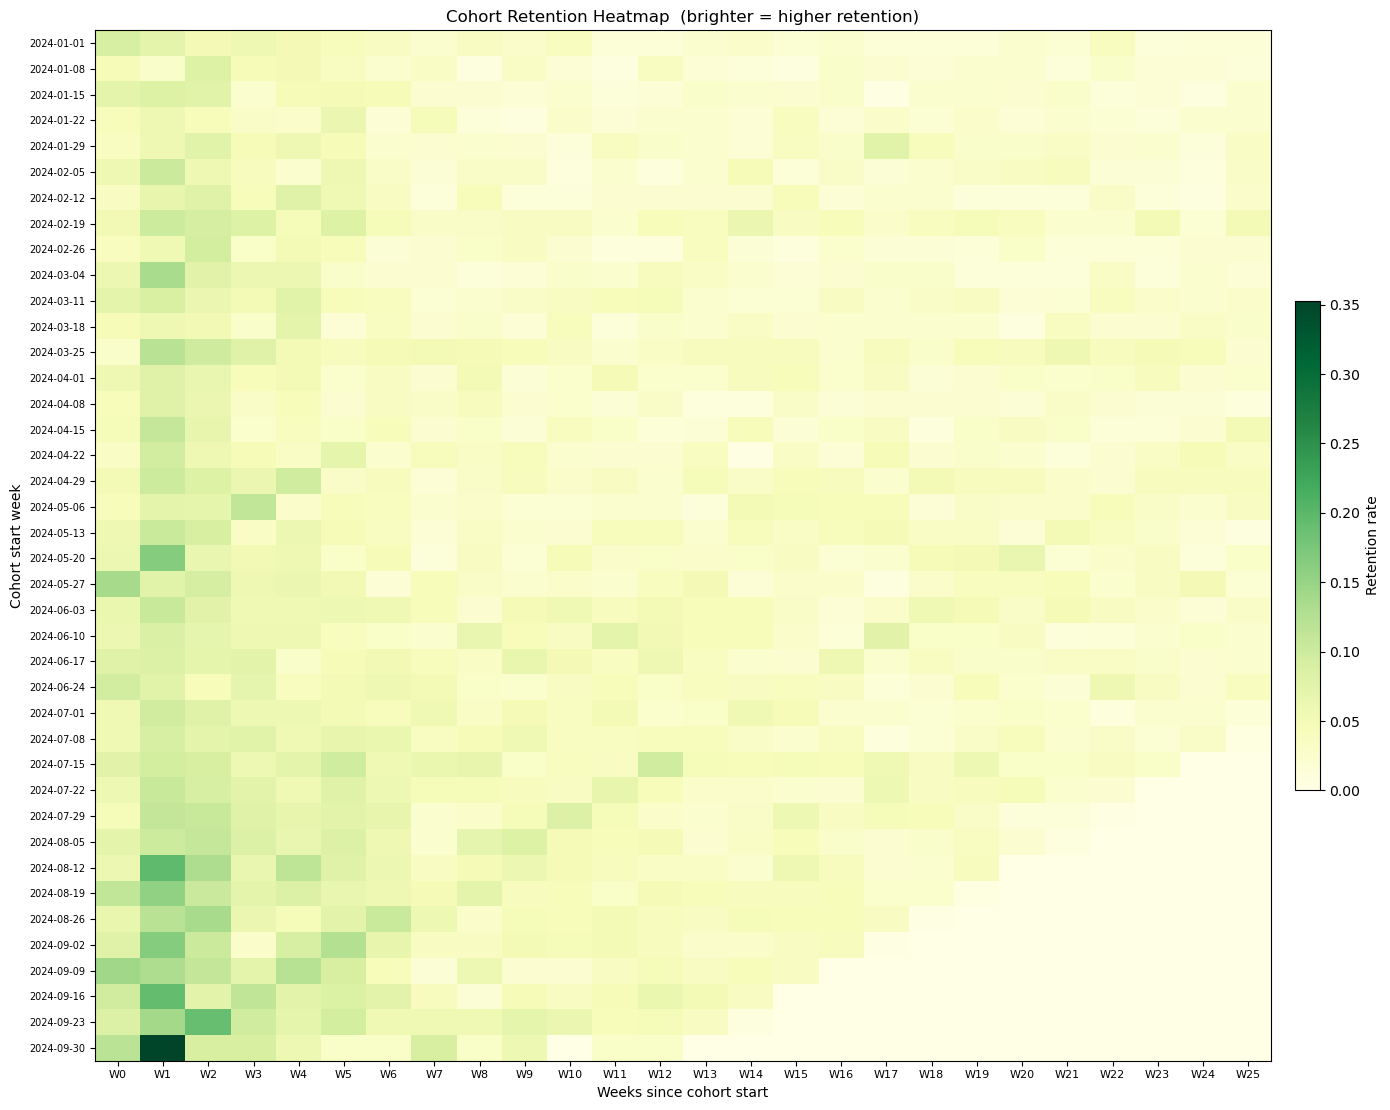

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse the pivot computed in Cell 3.
week_cols = sorted(
    [c for c in pivot.columns if c.startswith("week_")],
    key=lambda c: int(c.split("_")[1]),
)
heat = pivot.set_index("cohort_week")[week_cols].astype(float)

fig, ax = plt.subplots(figsize=(14, max(4, len(heat) * 0.28)))
im = ax.imshow(
    heat.values,
    aspect="auto",
    cmap="YlGn",
    vmin=0,
    vmax=float(np.nanmax(heat.values)),
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="Retention rate", fraction=0.02, pad=0.02)

ax.set_xticks(range(len(week_cols)))
ax.set_xticklabels([c.replace("week_", "W") for c in week_cols], fontsize=8)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels([str(w)[:10] for w in heat.index], fontsize=7)
ax.set_xlabel("Weeks since cohort start")
ax.set_ylabel("Cohort start week")
ax.set_title("Cohort Retention Heatmap  (brighter = higher retention)")

plt.tight_layout()
plt.show()

### Layman Explanation

Each row is one cohort, each column is a week, and the colour shows what fraction of that cohort was still active. Bright green = stronger retention; pale yellow = most users have churned; white/grey = data not yet available for that week.

Reading **left to right** reveals how fast a cohort loses users. Reading **top to bottom** shows whether newer cohorts are retaining better or worse than older ones — a quick way to spot trends before the models do.

### Technical Discussion

`pivot.set_index("cohort_week")[week_cols]` reshapes the already-computed wide DataFrame into a 2-D matrix suitable for `imshow`. Columns are sorted by week number so the x-axis runs chronologically left to right.

`np.nanmax` is used for `vmax` so that NaN cells (cohorts that haven't reached that week yet) don't distort the colour scale. `imshow` renders NaN as white by default with `YlGn`, which visually communicates "no data yet" without extra code.

`figheight = max(4, len(heat) * 0.28)` scales the figure vertically with the number of cohorts so row labels remain legible at any dataset size.

### Terminology

| Term | Meaning |
|------|---------|
| **Heatmap** | A 2-D grid where cell colour encodes a numeric value. More information-dense than line charts when comparing many groups simultaneously. |
| **`imshow`** | Matplotlib function that renders a 2-D array as a colour grid. Each array element becomes one pixel (or cell) in the image. |
| **Colormap (`YlGn`)** | A mapping from numeric values to colours. `YlGn` goes from pale yellow (low) to dark green (high), intuitive for retention (green = good). |
| **`vmin` / `vmax`** | The data values that map to the bottom and top of the colormap. Values outside this range are clipped to the extreme colour. |
| **NaN (Not a Number)** | A sentinel value representing missing data. Here it appears in columns for weeks a cohort has not yet reached — rendered as white. |

## Cell 8 — Predicted vs Actual (Test Set)

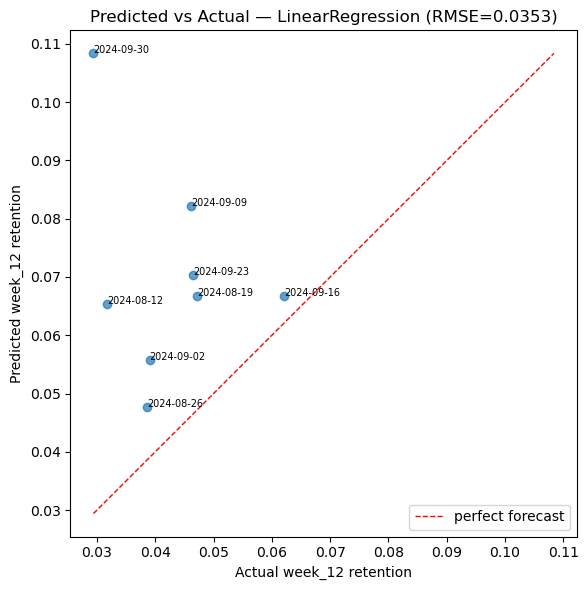

In [8]:
if len(test_weeks) >= 2 and best_preds_pd is not None:
    test_preds = best_preds_pd  # reuse predictions collected during the training loop

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(test_preds["label"], test_preds["prediction"], alpha=0.7)

    lo = min(test_preds[["label", "prediction"]].min())
    hi = max(test_preds[["label", "prediction"]].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="perfect forecast")

    for _, row in test_preds.iterrows():
        ax.annotate(str(row["cohort_week"]), (row["label"], row["prediction"]), fontsize=7)

    ax.set_xlabel(f"Actual {TARGET} retention")
    ax.set_ylabel(f"Predicted {TARGET} retention")
    ax.set_title(f"Predicted vs Actual — {best_name} (RMSE={best_rmse:.4f})")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Test set has {len(test_weeks)} cohort(s) — need >= 2 for a meaningful scatter plot. "
          "Run 'make generate-data' to produce more cohorts.")

### Layman Explanation

Each dot on this scatter plot is one test cohort. Its **horizontal position** is the actual week-12 retention we observed; its **vertical position** is what the model predicted. If every prediction were perfect, all dots would line up exactly on the red diagonal line.

Dots above the line mean the model over-predicted retention (too optimistic). Dots below mean it under-predicted (too pessimistic).

**What to expect given the model metrics:** With R²=−12.27 on 8 test cohorts, the dots will be scattered widely rather than tracking the diagonal. The predicted values cluster around the training-set mean while the actual values vary — a classic overfitting signature. Rather than validating good predictions, this plot serves as a diagnostic: it makes the model failure visible and concrete, showing exactly which cohorts were most mis-predicted and in which direction.

### Technical Discussion

`best_preds_pd` was collected from the cached prediction DataFrame during the training loop in Cell 5, using `.select("label", "prediction", "cohort_week").toPandas()`. Reusing it here avoids re-running model inference on the test set and ensures the scatter plot reflects exactly the predictions that determined which model won.

The identity line (perfect forecast) is constructed from `lo = min(actual ∪ predicted)` to `hi = max(actual ∪ predicted)`. Using the combined range ensures the diagonal always spans the full plot area.

`ax.annotate(str(row["cohort_week"]), ...)` labels each dot with its cohort identifier. With only 8 test cohorts, the labels are legible and useful — they allow specific cohorts to be traced back to their raw data for investigation.

**Expected visual pattern given R²=−12.27:** LinearRegression with a failed fit tends to compress all predictions toward the training-set mean. On the scatter plot this appears as a near-horizontal band of predicted values (small vertical spread) while actual values vary across the horizontal axis — the classic "mean-predicting" failure mode. The dots will form a roughly horizontal cloud rather than an upward diagonal. The wide spacing between predicted and actual values for some cohorts explains why RMSE (0.0353) is 2.6× larger than the baseline RMSE (0.0136).

The guard `len(test_weeks) >= 2 and best_preds_pd is not None` protects against two failure modes: a test set too small for a meaningful scatter plot, and a degenerate training run where no model produced a finite RMSE.

### Terminology

| Term | Meaning |
|------|---------|
| **Scatter plot** | A chart where each observation is a point, positioned by two numeric variables (here: actual vs predicted retention). Used to visualise the relationship between two quantities. |
| **Identity line (diagonal)** | The line `y = x` on a predicted-vs-actual plot. A perfect model would have all points on this line. |
| **Prediction error** | The difference between predicted and actual values: `error = predicted − actual`. Positive = over-prediction; negative = under-prediction. |
| **Test set evaluation** | Measuring model performance on data the model never saw during training — the gold standard for estimating real-world performance. |
| **Annotation** | A text label placed next to a data point to identify it. Here each dot is labelled with its cohort week. |
| **Residual** | Synonymous with prediction error. Plotting residuals (y − ŷ) vs fitted values (ŷ) is a standard regression diagnostic for detecting bias. |
| **`toPandas()`** | Materialises a Spark DataFrame on the driver. Use sparingly — only on small result sets. |

## Cell 9 — Cleanup

In [9]:
train.unpersist()
test.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
